In [76]:
!ls

bellabeat_user_profile_summary.csv  sample_data
dailyActivity_merged.csv	    sleepDay_merged.csv


In [77]:
# Import required libraries
import pandas as pd                 #for data manipulation
import numpy as np                  #numeric operations
import matplotlib.pyplot as plt     #visualizations
import seaborn as sns

#cleaner plot style
sns.set(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [78]:
# Load datasets
daily = pd.read_csv("dailyActivity_merged.csv")
sleep = pd.read_csv("sleepDay_merged.csv")

print("Data loaded successfully.")

Data loaded successfully.


In [79]:
#Inspect the Data Structure
#view first rows (5 rows default)

print("Daily Activity Preview:")
display(daily.head())

print("Sleep Data Preview:")
display(sleep.head())

Daily Activity Preview:


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


Sleep Data Preview:


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [80]:
#check rows and columns
print("Daily shape:", daily.shape)
print("Sleep shape:", sleep.shape)

Daily shape: (940, 15)
Sleep shape: (413, 5)


In [81]:
#Check column types and missing values

#Confirm data types

#Identify null values

#Spot incorrect formatting

print("Daily Info:")
daily.info()

print("\nSleep Info:")
sleep.info()

Daily Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14

In [82]:
#check for missing values

print("Missing values in Daily:")
print(daily.isnull().sum())

print("\nMissing values in Sleep:")
print(sleep.isnull().sum())

Missing values in Daily:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Missing values in Sleep:
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64


In [83]:
#Clean the data

#convert date column to datetime as it would not be possible to extract them as strings

daily["ActivityDate"] = pd.to_datetime(daily["ActivityDate"])
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])

print("Date columns converted.")

Date columns converted.


/tmp/ipython-input-532/4146971272.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])


In [84]:
#Remove deuplicate sleep records to avoid inaccurate data

sleep = sleep.drop_duplicates()
print("Duplicates removed from sleep dataset.")

Duplicates removed from sleep dataset.


In [85]:
#Create Date Columns (Remove Time Component)
#Sleep has time attached (00:00:00).
#We need pure date to merge.


daily["Date"] = daily["ActivityDate"].dt.date
sleep["Date"] = sleep["SleepDay"].dt.date

In [86]:
#add day of week
#we want weekday vs weekend analysis
daily["DayOfWeek"] = daily["ActivityDate"].dt.day_name()

In [87]:
#create total active minutes
#Executives care about total movement, not 3 separate intensity columns.

daily["TotalActiveMinutes"] = (
    daily["VeryActiveMinutes"] +
    daily["FairlyActiveMinutes"] +
    daily["LightlyActiveMinutes"]
)

In [88]:
#convert sleep minutes to hours
#Hours are easier to interpret than minutes.

sleep["SleepHours"] = sleep["TotalMinutesAsleep"] / 60

In [89]:
#merge datasets
#Now we can analyze activity + sleep together

df = pd.merge(
    daily,
    sleep,
    on=["Id", "Date"],
    how="left"
)

print("Merged dataset shape:", df.shape)
display(df.head())

Merged dataset shape: (940, 23)


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,SedentaryMinutes,Calories,Date,DayOfWeek,TotalActiveMinutes,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepHours
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,728,1985,2016-04-12,Tuesday,366,2016-04-12,1.0,327.0,346.0,5.450000
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,776,1797,2016-04-13,Wednesday,257,2016-04-13,2.0,384.0,407.0,6.400000
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,...,1218,1776,2016-04-14,Thursday,222,NaT,NaN,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,...,726,1745,2016-04-15,Friday,272,2016-04-15,1.0,412.0,442.0,6.866667
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,...,773,1863,2016-04-16,Saturday,267,2016-04-16,2.0,340.0,367.0,5.666667


In [90]:
#Average steps
print("Average Daily Steps:", daily["TotalSteps"].mean())

Average Daily Steps: 7637.9106382978725


In [91]:
#Average calories
print("Average Calories Burned:", daily["Calories"].mean())

Average Calories Burned: 2303.609574468085


In [92]:
#average sleep hours
print("Average Sleep Hours:", sleep["SleepHours"].mean())

Average Sleep Hours: 6.986219512195122


In [93]:
#correlation analyis
#If close to 1 → strong relationship.

correlation = daily["TotalSteps"].corr(daily["Calories"])
print("Correlation between Steps and Calories:", correlation)

Correlation between Steps and Calories: 0.5915680862453355


In [94]:
#group by day of week

steps_by_day = daily.groupby("DayOfWeek")["TotalSteps"].mean()

# Order properly
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
steps_by_day = steps_by_day.reindex(order)

display(steps_by_day)

,TotalSteps
DayOfWeek,
Monday,7780.866667
Tuesday,8125.006579
Wednesday,7559.373333
Thursday,7405.836735
Friday,7448.230159
Saturday,8152.975806
Sunday,6933.231405


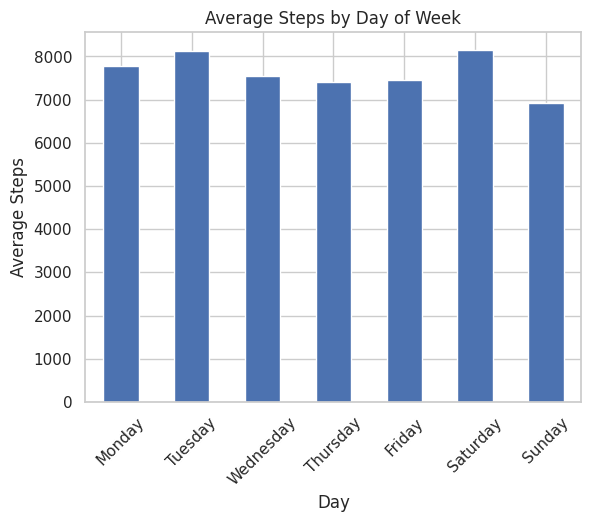

In [95]:
#visualizations

plt.figure()
steps_by_day.plot(kind="bar")
plt.title("Average Steps by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)
plt.show()

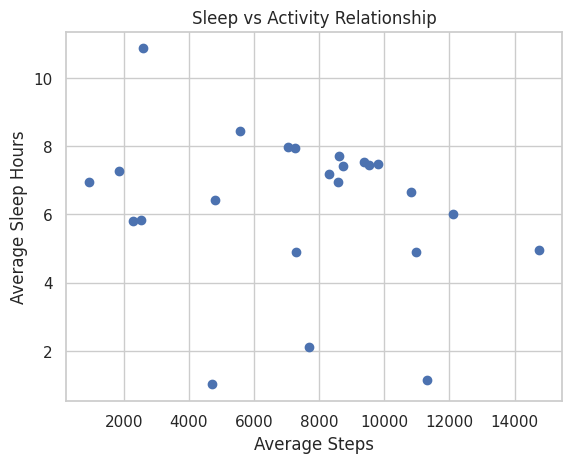

In [96]:
#sleep vs steps scatter

plt.figure()
plt.scatter(user_summary["AvgSteps"], user_summary["AvgSleepHours"])
plt.xlabel("Average Steps")
plt.ylabel("Average Sleep Hours")
plt.title("Sleep vs Activity Relationship")
plt.show()

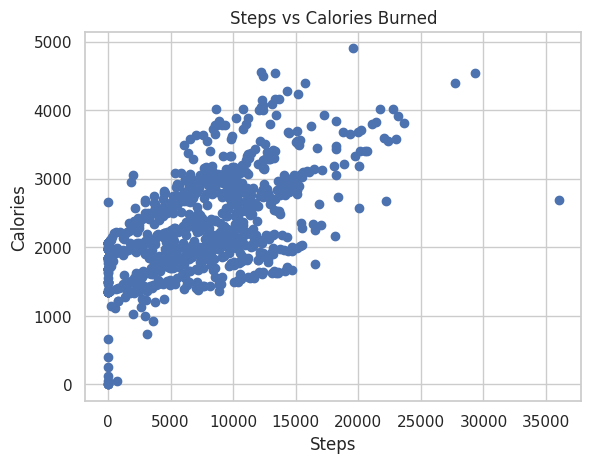

In [97]:
#steps vs calories

plt.figure()
plt.scatter(daily["TotalSteps"], daily["Calories"])
plt.title("Steps vs Calories Burned")
plt.xlabel("Steps")
plt.ylabel("Calories")
plt.show()

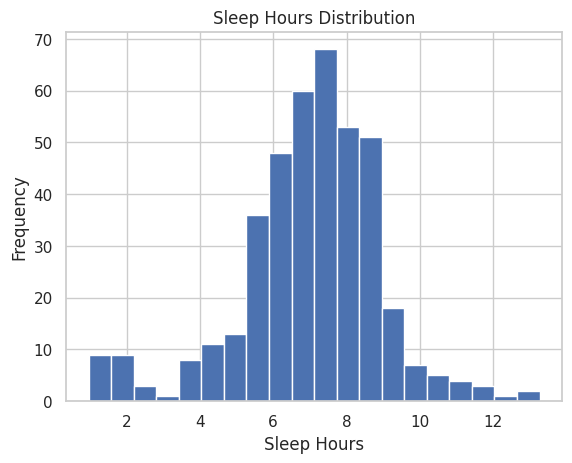

In [98]:
#sleep distribution

plt.figure()
plt.hist(sleep["SleepHours"], bins=20)
plt.title("Sleep Hours Distribution")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")
plt.show()

In [99]:
#create user-level summary
#This transforms daily logs → user profiles

user_summary = df.groupby("Id").agg({
    "TotalSteps": "mean",
    "Calories": "mean",
    "TotalActiveMinutes": "mean",
    "SedentaryMinutes": "mean",
    "SleepHours": "mean"
}).reset_index()

user_summary.columns = [
    "Id",
    "AvgSteps",
    "AvgCalories",
    "AvgActiveMinutes",
    "AvgSedentaryMinutes",
    "AvgSleepHours"
]

display(user_summary.head())

,Id,AvgSteps,AvgCalories,AvgActiveMinutes,AvgSedentaryMinutes,AvgSleepHours
0,1503960366,12116.741935,1816.419355,277.806452,848.161290,6.004667
1,1624580081,5743.903226,1483.354839,167.967742,1257.741935,NaN
2,1644430081,7282.966667,2811.300000,209.400000,1161.866667,4.900000
3,1844505072,2580.064516,1573.483871,116.870968,1206.612903,10.866667
4,1927972279,916.129032,2172.806452,40.677419,1317.419355,6.950000


In [100]:
#export clean dataset

user_summary.to_csv("bellabeat_user_profile_summary.csv", index=False)
print("Summary file created.")

Summary file created.


In [101]:
from google.colab import files
files.download("bellabeat_user_profile_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>